In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Wholesale customers data.csv")

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [5]:
df.shape

(440, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [7]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [16]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
x=df[features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled[:5]

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

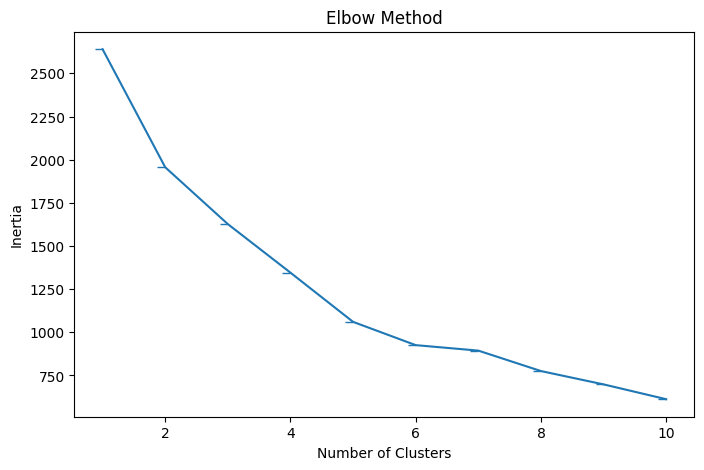

In [22]:
from sklearn.cluster import KMeans

inertia = []

k_range =range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker =0 )
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [28]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

df['KMeans_Cluster'] = kmeans_labels
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,270
3,96
2,63
1,10
4,1


In [29]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

df['DBSCAN_Cluster'] = dbscan_labels
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,393
-1,47


In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print('Explained Variance Ratio:', pca.explained_variance_ratio_)
print('Total Explained Variance Ratio:', sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.44082893 0.283764  ]
Total Explained Variance Ratio: 0.7245929240774496


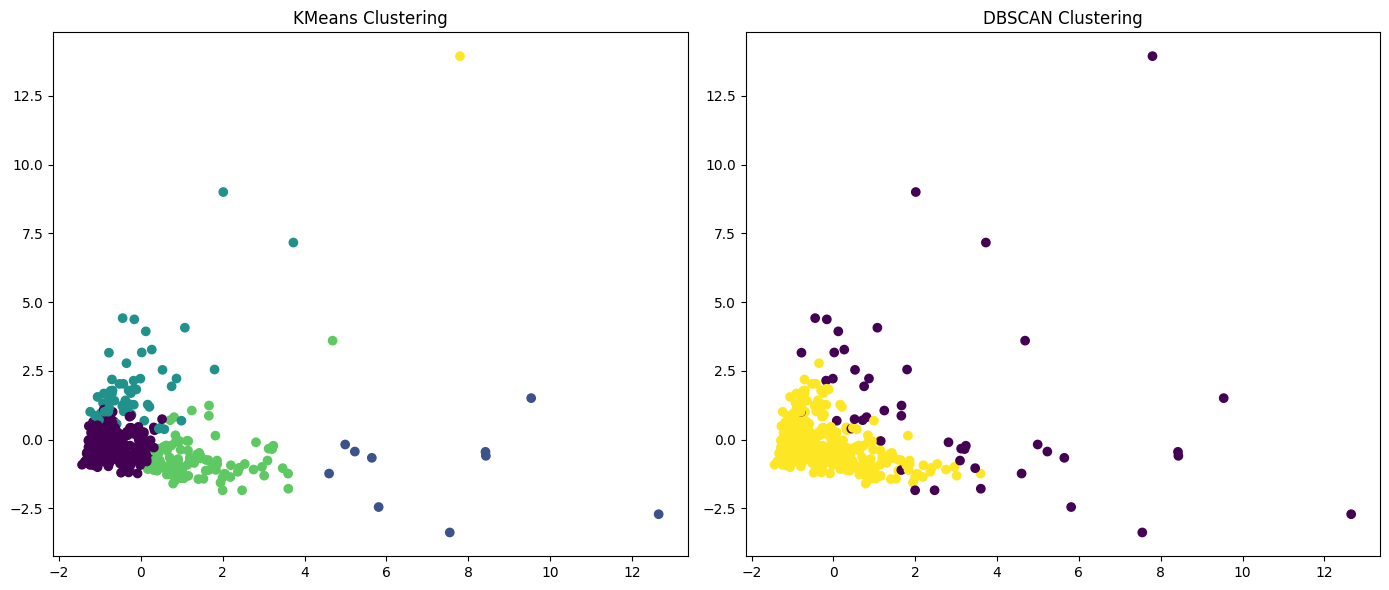

In [36]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.scatter(x_pca[:,0], x_pca[:,1], c=kmeans_labels)
plt.title('KMeans Clustering')

plt.subplot(1,2,2)
plt.scatter(x_pca[:,0], x_pca[:,1], c=dbscan_labels)
plt.title('DBSCAN Clustering')

plt.tight_layout()
plt.show()

In [42]:
print(df.groupby('KMeans_Cluster')[features].mean())
print(df.groupby('DBSCAN_Cluster')[features].mean())

                       Fresh          Milk       Grocery        Frozen  \
KMeans_Cluster                                                           
0                9092.155556   2967.759259   3807.411111   2271.759259   
1               15964.900000  34708.500000  48536.900000   3054.600000   
2               32957.984127   4997.349206   5884.761905   8422.841270   
3                5754.166667  10866.604167  16607.104167   1464.125000   
4               36847.000000  43950.000000  20170.000000  36534.000000   

                Detergents_Paper    Delicassen  
KMeans_Cluster                                  
0                     989.814815    978.962963  
1                   24875.200000   2942.800000  
2                     954.603175   2462.968254  
3                    7202.875000   1813.385417  
4                     239.000000  47943.000000  
                       Fresh         Milk       Grocery       Frozen  \
DBSCAN_Cluster                                                    

Clusters Findings:


1.   K-Means split customers into 5 groups. Most fall into Cluster 0, low spending across the board, pretty average buyers
2.   Cluster 1 (10 customers) spends a ton on Milk, Grocery and Detergents_Paper, these look like bulk retail or grocery store buyers


1.   Cluster 2 (63 customers) spends heavily on Fresh and Frozen but not much else, probably restaurants or hotels that need fresh ingredients rather than packaged goods
2.   Cluster 4 is just 1 customer who spends a huge amount on almost everything, especially Delicassen, basically one massive outlier account


1.   DBSCAN kept things simpler. It grouped 393 customers into one big "typical" cluster and flagged the other 47 as noise instead of forcing them into separate groups
2.   Those 47 flagged customers spend noticeably more across every category, so DBSCAN is basically saying the same thing K-Means found, just without splitting the high spenders into subgroups


1.  Both algorithms land on the same core idea: most customers behave pretty similarly, but there's a real minority of high-volume buyers worth treating differently








